<a href="https://colab.research.google.com/github/Jonchyk/Datamgmt/blob/main/Capstone_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Set Up

In [59]:
#---------------------------SETUP----------------------------------
#get useful libraries
import time, os, sys, re #basics
import zipfile, json, datetime, string   #string for annotating points in scatter
import numpy as np #basic math
# Install tabula-py using pip
!pip install tabula-py
# Import the correct module
from tabula import read_pdf
import statsmodels.api as sm
from statsmodels.formula.api import ols

!pip install pyreadstat


import matplotlib.pyplot as plt #import pylab as plt #apparently discouraged now:
 #https://stackoverflow.com/questions/11469336/what-is-the-difference-between-pylab-and-pyplot
 #https://www.tutorialspoint.com/matplotlib/matplotlib_pylab_module.htm

import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler
#s4 = Styler(df4, uuid_len=0, cell_ids=False)

import urllib  #weird, guess need to have os and pandas imported for this to work  %TODO/LATER ditch it, its weird anyway, just use wget/curl

from google.colab import files

#import webbrowser

import seaborn as sns

from google.colab import data_table
data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )

#many tricks how to extend notebook functionality
#https://coderzcolumn.com/tutorials/python/list-of-useful-magic-commands-in-jupyter-notebook-lab
#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#MAGICS and THEMES/STYLES: important! does affect not just shading/colors, but also fonts, spacing, etc
#(even if you only select default (v not selecting anything) [but does seem to work better if you do make explicit sleections])

###magics: https://ipython.readthedocs.io/en/stable/interactive/magics.html
#most essential setup for vis: it does affect vis! careful!! stick with inline, maybe notebook; others mostly for non-notebook, eg spyder environ
#https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html recomends *inline*!
#show current one:
#%matplotlib
#%matplotlib --list
#interactive plots:
#%matplotlib notebook
#static images of your plot:
%matplotlib inline
#may play with this one and other magics (btw default is probably agg)
#%matplotlib nbagg
##https://www.marktechpost.com/2023/10/20/6-magic-commands-for-jupyter-notebooks-in-python-data-science/
#%%latex
#%ai
#%run
#%writefile
#%history -n

###themes/styles: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
#https://jakevdp.github.io/PythonDataScienceHandbook/04.11-settings-and-stylesheets.html
#https://matplotlib.org/stable/tutorials/introductory/customizing.html
#here more about art and style than under the hood functionality as with magics, explore and experiment
#many may find 'default' or seaborn ones more pleasing; my fav 'classic' is back from 90s ;)
#plt.style.available #list available styles :) may install more
#plt.style.use('default') # more delicate subtle than classic
plt.style.use('classic')  #  'seaborn-whitegrid' 'seaborn-white' 'seaborn-poster'
# btw: magics v theme/style sequence matters, eg if i specify classic style before inline magic, i wouldnt get grey bounding box im getting

#sometimes have to install library which you get from https://pypi.org/
#!pip install geopandas

In [60]:
import plotly.express as px
from statsmodels.stats.multicomp import pairwise_tukeyhsd



#Datasets

#Early Grade Reading Assessment: received with permission from employer, RTI
This is a dataset from the Okuu Keremet! Program's 2021 Baseline study. It has a wealth of information, ranging from G2 teacher, head teacher, and librarian interviews, classroom observations, math results, and early grade reading results. For the purpose of my capstone study, I will be using this dataset, cleaned and targeting specifically the EGRA subtasks: Oral Reading, Oral Reading Comprehension, Invented Word Reading, and Silent Reading Comprehension.

# 2021 NST Data.
This dataset will be to review and verify the NST study done in 2017 by Shamatov and Bahry, which inspired this research into early grade reading results on region and language of instruction.


## Early Grade Reading Assessment Data

In [61]:
# let's load the data set - this is the EGRA file
!wget --no-check-certificate 'https://docs.google.com/spreadsheets/d/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU/export?format=csv' -O Datareading.csv


--2025-03-25 22:24:02--  https://docs.google.com/spreadsheets/d/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU/export?format=csv
Resolving docs.google.com (docs.google.com)... 74.125.26.100, 74.125.26.138, 74.125.26.101, ...
Connecting to docs.google.com (docs.google.com)|74.125.26.100|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://doc-0c-7s-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/95kl6p7guflrjle6ti6otu7th0/1742941440000/113781219181981321798/*/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU?format=csv [following]
--2025-03-25 22:24:03--  https://doc-0c-7s-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/95kl6p7guflrjle6ti6otu7th0/1742941440000/113781219181981321798/*/1Rq8nK25uEKsjwwcu0Sr1IF1oBD6N2BwbmFW5VeiGAfU?format=csv
Resolving doc-0c-7s-sheets.googleusercontent.com (doc-0c-7s-sheets.googleusercontent.com)... 74.125.139.132, 2607:f8b0:400c:c05::84
Connecting to doc-0c-7s-sheets.googleusercontent.c

In [62]:
egra = pd.read_csv('Datareading.csv')#let's take a look at this
egra.describe()
#oh man.


<ipython-input-62-5d8047de8398>:1: DtypeWarning:

Columns (15,18,19,20,21,22,23,24,25,27,28,30,31,32,33,34,35,36,37,38,39,44,45,46,50,52,58,59,60,67,69,70,71,80,90,95,96,100,101,102,104,108,109,110,115,121,128,132,133,134,136,137,138,139,140,141,146,147,148,152,155,156,157,158,159,167,168,176,178,179,185,192,200,201,212,219,220,229,230,241,242,243,245,253,254,263,267,268,269,271,276,277,278,280,281,290,291,292,293,294,300,301,305,306,307,311,312,313,314,315,323,324,326,327,328,333,337,338,391,392,393,396,397,452,453,454,455,456,457,458,459,460,461,462,463,464,465,468,469,475,476,478,479,485,486,488,489,500,501,503,504,510,511,513,514,520,521,523,524,533,535,549,551,555,559,563,565,567,569,571,572,573,574,575,576,582,583,584,585,586,587,588,592,593,604,605,608,610,624,626,629,630,631,632,633,634,637,638,639,640,642,643,644,645,647,648,649,650,652,653,654,655,660,661,662,663,664,665,667,670,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,69

,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,...,location_schooldistrict_level,location_schoolschool_parent,location_schoolschool_id,location_schoolschool_level,ci_,invent_worditem_at_time,oral_readitem_at_time,sil_readitem_at_time,userprofileitem1female,strata1
count,5275,5275,5275,5275,5275,5275,5275,5275,5275,5275,...,31,31,31,31,1,1,1,1,1214.0,5275
unique,10,54,233,5,5,3,9,233,3,9,...,2,3,4,2,1,1,1,1,3.0,13
top,Жалал-Абадская,Сузакский,20901461,Kyrgyz,Kyrgyz,Rural,K,СШ №66,Treatment,K,...,District,БаткенскаяЛейлекский,1S36560804,School,ci_,invent_word.item_at_time,oral_read.item_at_time,b_oral_read.item_at_time,1.0,2024--Program Kyrgyz
freq,1155,429,41,2874,2874,3797,1772,41,3139,1772,...,30,20,10,30,1,1,1,1,711.0,729


In [63]:
egra.head(2)
#One thing I really like about the way my colleague set this up, is there is a dsecription of each column in index 0. This makes it a LOT easier to figure out what to keep!

,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,...,location_schooldistrict_level,location_schoolschool_parent,location_schoolschool_id,location_schoolschool_level,ci_,invent_worditem_at_time,oral_readitem_at_time,sil_readitem_at_time,userprofileitem1female,strata1
0,In which region is the student's school located?,In which district is the student's school loca...,School's code within country.,Language of Assessment,For what language of instruction was this scho...,Urban/Rural,School Language(s) of Instruction,schoolname,Treament/Comparison Indicator,School Language(s) of Instruction,...,location_school.District_level,location_school.School_parent,location_school.School_id,location_school.School_level,ci_,invent_word.item_at_time,oral_read.item_at_time,b_oral_read.item_at_time,user-profile.item1.female,strata1
1,Ошская,Араванский,1S32310502,Kyrgyz,Kyrgyz,Rural,KRU,СШ им.С.Шарипова,Control,KRU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz


In [64]:
#let's check what we have. I know there's baseline and endline data here. We want just the baseline data, prior to program interventions
egra['g2_year'].value_counts()


,count
g2_year,
2024,2692
2021,1559
2021,1023
Grade 2 Read/Math Year,1


In [65]:
#Strange. I have two identical values for 2021. what's up?
egra['g2_year'].apply(type)
egra['g2_year'].dtypes

#Looks like I have strings and integers...I want to convery this all to string


,g2_year
0,<class 'str'>
1,<class 'str'>
2,<class 'str'>
3,<class 'str'>
4,<class 'str'>
...,...
5270,<class 'int'>
5271,<class 'int'>
5272,<class 'int'>
5273,<class 'int'>


dtype('O')

In [66]:
#let's see if we can convert all our "2021"'s to a string so its the same value
egra['g2_year'] = egra['g2_year'].apply(lambda x: '2021' if str(x) == '2021' else x)


In [67]:
#let's run it again, looks like it worked!
egra['g2_year'].value_counts()


,count
g2_year,
2024,2692
2021,2582
Grade 2 Read/Math Year,1


In [68]:
#now I can finally filter to the data I want.
baseline = egra[egra['g2_year'] == '2021']

In [69]:
baseline.count()
#bingo!

,0
region,2582
district,2582
school_code,2582
language,2582
language_name,2582
...,...
invent_worditem_at_time,0
oral_readitem_at_time,0
sil_readitem_at_time,0
userprofileitem1female,0


In [70]:
baseline.groupby('region').size()
baseline.groupby('district').size()
#Breakdown by region, and by group within the baseline study of 2500 observations.
#will need to rename this, but gives some nice quick insights as to what i'll be looking at for my roll up by region!


,0
region,
Баткенская,301
Жалал-Абадская,580
Иссык-Кульская,230
Нарынская,96
Ошская,437
Таласская,140
Чуйская,341
г. Бишкек,318
г. Ош,139


,0
district,
Ак-Суйский,59
Аксыйский,25
Ала-Букинский,25
Алайский,10
Араванский,78
Ат-Башинский,18
Базар-Коргонский,98
Бакай-Атинский,30
Баткенский,30


##NST Dataset

In [71]:
# get the file
!wget --no-check-certificate "https://drive.google.com/uc?export=download&id=1BQ7RpjsBdBTHx-qqBUDu6WaukjNza2aq" -O nst2021.pdf


--2025-03-25 22:24:13--  https://drive.google.com/uc?export=download&id=1BQ7RpjsBdBTHx-qqBUDu6WaukjNza2aq
Resolving drive.google.com (drive.google.com)... 172.217.203.139, 172.217.203.113, 172.217.203.100, ...
Connecting to drive.google.com (drive.google.com)|172.217.203.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1BQ7RpjsBdBTHx-qqBUDu6WaukjNza2aq&export=download [following]
--2025-03-25 22:24:13--  https://drive.usercontent.google.com/download?id=1BQ7RpjsBdBTHx-qqBUDu6WaukjNza2aq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.26.132, 2607:f8b0:400c:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.26.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11199477 (11M) [application/octet-stream]
Saving to: ‘nst2021.pdf’

nst2021.pdf         100%[===================>]  10.68M  58.9MB/s 

In [72]:
Nat = read_pdf('nst2021.pdf', pages='25-29',multiple_tables=True, stream=True)
Nat
#well. the stream function helps but this is still horrifying. I need to figure out how to essentially take the first two tables from each, combine them, then add country + region. Then repeat that process 8 or 9 times, then merge, all while double checking the pdf to ensure this matches the reported data


[     Unnamed: 0    Unnamed: 1    Unnamed: 2 стандартноe      Unnamed: 3  \
 0          язык    количество  средн. знач.  отклонение     коэффициент   
 1  тестирования    участников      тестовых    тестовых      надежности   
 2           NaN  тестирования        баллов         NaN  Альфа Кронбаха   
 3           NaN           NaN           NaN      баллов             NaN   
 4    Кыргызский         27500         114.0        29.2            0.91   
 5       Русский         17520         130.7        33.4            0.93   
 6      В целом:         45020         120.5        32.0            0.93   
 
      Unnamed: 4    Unnamed: 5    Unnamed: 6  
 0          язык    количество  средн. знач.  
 1  тестирования   зачисленных      тестовых  
 2           NaN  абитуриентов        баллов  
 3           NaN           NaN           NaN  
 4    Кыргызский          2877         145.1  
 5       Русский          1248         156.7  
 6      В целом:          4125         148.6  ,
      Unnamed

In [73]:
print(type(Nat[0]))  # Check the type of the first element
print(Nat[0])        # Print the first element


<class 'pandas.core.frame.DataFrame'>
     Unnamed: 0    Unnamed: 1    Unnamed: 2 стандартноe      Unnamed: 3  \
0          язык    количество  средн. знач.  отклонение     коэффициент   
1  тестирования    участников      тестовых    тестовых      надежности   
2           NaN  тестирования        баллов         NaN  Альфа Кронбаха   
3           NaN           NaN           NaN      баллов             NaN   
4    Кыргызский         27500         114.0        29.2            0.91   
5       Русский         17520         130.7        33.4            0.93   
6      В целом:         45020         120.5        32.0            0.93   

     Unnamed: 4    Unnamed: 5    Unnamed: 6  
0          язык    количество  средн. знач.  
1  тестирования   зачисленных      тестовых  
2           NaN  абитуриентов        баллов  
3           NaN           NaN           NaN  
4    Кыргызский          2877         145.1  
5       Русский          1248         156.7  
6      В целом:          4125         1

In [74]:
Nat[0]
#we have lift off!!!!!



,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,27500,114.0,29.2,0.91,Кыргызский,2877,145.1
5,Русский,17520,130.7,33.4,0.93,Русский,1248,156.7
6,В целом:,45020,120.5,32.0,0.93,В целом:,4125,148.6


In [75]:
#ok! Let's drop "standardnoe", "unnamed 3, and "unnamed 4".
Nat[0].drop(columns=['стандартноe', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
Nat[0]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,количество,средн. знач.
1,тестирования,участников,тестовых,зачисленных,тестовых
2,NaN,тестирования,баллов,абитуриентов,баллов
3,NaN,NaN,NaN,NaN,NaN
4,Кыргызский,27500,114.0,2877,145.1
5,Русский,17520,130.7,1248,156.7
6,В целом:,45020,120.5,4125,148.6


In [76]:
#looking good. Now we want to rename columns
Nat[0].rename(columns={
    'Unnamed: 0': 'language',
    'Unnamed: 1': 'Total_quantity',
    'Unnamed: 2': 'Avg_score',
    'Unnamed: 5': 'Award_quantity',
    'Unnamed: 6': 'Award_average'
}, inplace=True)
Nat[0]


,language,Total_quantity,Avg_score,Award_quantity,Award_average
0,язык,количество,средн. знач.,количество,средн. знач.
1,тестирования,участников,тестовых,зачисленных,тестовых
2,NaN,тестирования,баллов,абитуриентов,баллов
3,NaN,NaN,NaN,NaN,NaN
4,Кыргызский,27500,114.0,2877,145.1
5,Русский,17520,130.7,1248,156.7
6,В целом:,45020,120.5,4125,148.6


In [77]:
Nat[0]['country'] = 'kyrgyzstan'
Nat[0]['region'] = 'kyrgyzstan'
Nat[0]
#excellent! That's one table almost done.
#one final piece is to drop the indexes 0, 1, 2 and 3. We only have needed data in index 4-6.


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
0,язык,количество,средн. знач.,количество,средн. знач.,kyrgyzstan,kyrgyzstan
1,тестирования,участников,тестовых,зачисленных,тестовых,kyrgyzstan,kyrgyzstan
2,NaN,тестирования,баллов,абитуриентов,баллов,kyrgyzstan,kyrgyzstan
3,NaN,NaN,NaN,NaN,NaN,kyrgyzstan,kyrgyzstan
4,Кыргызский,27500,114.0,2877,145.1,kyrgyzstan,kyrgyzstan
5,Русский,17520,130.7,1248,156.7,kyrgyzstan,kyrgyzstan
6,В целом:,45020,120.5,4125,148.6,kyrgyzstan,kyrgyzstan


In [78]:
Nat[0].drop(index=[0,1,2,3], inplace=True)  # Drops rows
Nat[0]
#hooray! Managed to take one table from pdf and finally get this into a useable format. This needs to be repeated a bunch of times for each of the "nat [#], then merged I suppose
#showing as error, will clear when I rerun, all good below!

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,27500,114.0,2877,145.1,kyrgyzstan,kyrgyzstan
5,Русский,17520,130.7,1248,156.7,kyrgyzstan,kyrgyzstan
6,В целом:,45020,120.5,4125,148.6,kyrgyzstan,kyrgyzstan


In [79]:
NSTTOTAL = pd.DataFrame(Nat[0])
NSTTOTAL
#and its a full dataframe!!! one down, every region left to go.

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,27500,114.0,2877,145.1,kyrgyzstan,kyrgyzstan
5,Русский,17520,130.7,1248,156.7,kyrgyzstan,kyrgyzstan
6,В целом:,45020,120.5,4125,148.6,kyrgyzstan,kyrgyzstan


Ok! So I can load a pdf page using tabula, and have found a mostly simple solution to rebuild out the identified "list" tables from tabula into workeable dataframes. I'll need to cross reference each table to the pdf to ensure it extracts properly, but we have the first working model above, and a plan for merging it all together into one final dataset :-)! talk about painful.






In [80]:
Nat[1]
#in reviewing, this matches the data for Batken. Let's repeat all our prior operations


,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,2830,117.2,30.5,0.91,Кыргызский,409,145.8
5,Русский,440,120.5,31.8,0.93,Русский,40,148.6
6,В целом:,3270,117.6,30.7,0.93,В целом:,449,146.0


In [81]:
Nat[1].drop(columns=['стандартноe', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
#looking good. Now we want to rename columns
Nat[1].rename(columns={
    'Unnamed: 0': 'language',
    'Unnamed: 1': 'Total_quantity',
    'Unnamed: 2': 'Avg_score',
    'Unnamed: 5': 'Award_quantity',
    'Unnamed: 6': 'Award_average'
}, inplace=True)
Nat[1].drop(index=[0,1,2,3], inplace=True)  # Drops rows
Nat[1]['country'] = 'kyrgyzstan'
Nat[1]['region'] = 'Batken'
Nat[1]#check We got it! let's take the process forward and make this a dataframe with the region name, then we can do one massive merge operation


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Русский,440,120.5,40,148.6,kyrgyzstan,Batken
6,В целом:,3270,117.6,449,146.0,kyrgyzstan,Batken


In [82]:
Batken = pd.DataFrame(Nat[1])
Batken#done. Next one!

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Русский,440,120.5,40,148.6,kyrgyzstan,Batken
6,В целом:,3270,117.6,449,146.0,kyrgyzstan,Batken


In [83]:
Nat[2]# this aligns with Bishkek!

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,3399,118.7,31.1,0.91,Кыргызский,245,149.5
5,Русский,7325,141.3,33.3,0.93,Русский,492,164.6
6,В целом:,10724,134.2,34.3,0.93,В целом:,737,159.5


In [84]:
Nat[2].drop(columns=['стандартноe', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
#looking good. Now we want to rename columns
Nat[2].rename(columns={
    'Unnamed: 0': 'language',
    'Unnamed: 1': 'Total_quantity',
    'Unnamed: 2': 'Avg_score',
    'Unnamed: 5': 'Award_quantity',
    'Unnamed: 6': 'Award_average'
}, inplace=True)
Nat[2].drop(index=[0,1,2,3], inplace=True)  # Drops rows
Nat[2]['country'] = 'kyrgyzstan'
Nat[2]['region'] = 'Bishkek'
Bishkek = pd.DataFrame(Nat[2])



In [85]:
Bishkek#check and done!

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,3399,118.7,245,149.5,kyrgyzstan,Bishkek
5,Русский,7325,141.3,492,164.6,kyrgyzstan,Bishkek
6,В целом:,10724,134.2,737,159.5,kyrgyzstan,Bishkek


In [86]:
Nat[3]#this looks like Osh City. rinse and repeat.

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,1032,122.3,33.6,0.91,Кыргызский,129,156.2
5,Русский,1208,130.0,34.1,0.93,Русский,94,162.7
6,В целом:,2240,126.4,34.0,0.93,В целом:,223,158.9


In [87]:
Nat[3].drop(columns=['стандартноe', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
#looking good. Now we want to rename columns
Nat[3].rename(columns={
    'Unnamed: 0': 'language',
    'Unnamed: 1': 'Total_quantity',
    'Unnamed: 2': 'Avg_score',
    'Unnamed: 5': 'Award_quantity',
    'Unnamed: 6': 'Award_average'
}, inplace=True)
Nat[3].drop(index=[0,1,2,3], inplace=True)  # Drops rows
Nat[3]['country'] = 'kyrgyzstan'
Nat[3]['region'] = 'Osh_city'
Osh_city = pd.DataFrame(Nat[3])
Osh_city

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,1032,122.3,129,156.2,kyrgyzstan,Osh_city
5,Русский,1208,130.0,94,162.7,kyrgyzstan,Osh_city
6,В целом:,2240,126.4,223,158.9,kyrgyzstan,Osh_city


In [88]:
Nat[4]
#comparing back to the pdf, this is the scores for Jalal-Abad

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,4744,112.3,27.1,0.91,Кыргызский,434,143.2
5,Русский,1214,123.0,31.7,0.93,Русский,91,155.5
6,В целом:,5958,114.4,28.5,0.93,В целом:,525,145.3


In [89]:
Nat[4].drop(columns=['стандартноe', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
#looking good. Now we want to rename columns
Nat[4].rename(columns={
    'Unnamed: 0': 'language',
    'Unnamed: 1': 'Total_quantity',
    'Unnamed: 2': 'Avg_score',
    'Unnamed: 5': 'Award_quantity',
    'Unnamed: 6': 'Award_average'
}, inplace=True)
Nat[4].drop(index=[0,1,2,3], inplace=True)  # Drops rows
Nat[4]['country'] = 'kyrgyzstan'
Nat[4]['region'] = 'Jalal_Abad'
Jalal_Abad = pd.DataFrame(Nat[4])
Jalal_Abad

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,4744,112.3,434,143.2,kyrgyzstan,Jalal_Abad
5,Русский,1214,123.0,91,155.5,kyrgyzstan,Jalal_Abad
6,В целом:,5958,114.4,525,145.3,kyrgyzstan,Jalal_Abad


In [90]:
Nat[5]
#this is Issyk-Kul


,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,3070,111.7,28.0,0.91,Кыргызский,314,141.2
5,Русский,1656,124.4,31.9,0.93,Русский,143,147.4
6,В целом:,4726,116.2,30.0,0.93,В целом:,457,143.2


In [91]:
Nat[6]
#this is Naryn

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,2577,115.8,29.1,0.91,Кыргызский,369,143.8
5,Русский,790,119.4,31.6,0.93,Русский,75,142.6
6,В целом:,3367,116.6,29.7,0.93,В целом:,444,143.6


In [92]:
Nat[7]
#this is Osh

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,5598,111.9,29.2,0.91,Кыргызский,683,146.0
5,Русский,709,115.2,30.2,0.93,Русский,63,154.7
6,В целом:,6307,112.3,29.3,0.93,В целом:,746,146.7


In [93]:
Nat[8]
#Talas!

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,1551,120.2,29.3,0.91,Кыргызский,161,146.9
5,Русский,343,125.8,29.4,0.93,Русский,37,151.2
6,В целом:,1894,121.2,29.4,0.93,В целом:,198,147.7


In [94]:
Nat[9]
#last but not least, Chui

,Unnamed: 0,Unnamed: 1,Unnamed: 2,стандартноe,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,язык,количество,средн. знач.,отклонение,коэффициент,язык,количество,средн. знач.
1,тестирования,участников,тестовых,тестовых,надежности,тестирования,зачисленных,тестовых
2,NaN,тестирования,баллов,NaN,Альфа Кронбаха,NaN,абитуриентов,баллов
3,NaN,NaN,NaN,баллов,NaN,NaN,NaN,NaN
4,Кыргызский,2699,106.7,25.9,0.91,Кыргызский,133,137.0
5,Русский,3835,122.4,29.8,0.93,Русский,213,150.6
6,В целом:,6534,115.9,29.3,0.93,В целом:,346,145.4


In [95]:
# Iterate through the specified dataframes! What a good idea. Should have listed each 0-9 as a variable from the very start.
for i in [5, 6, 7, 8, 9]:
    # Drop unnecessary columns
    Nat[i].drop(columns=['стандартноe', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

    # Rename columns
    Nat[i].rename(columns={
        'Unnamed: 0': 'language',
        'Unnamed: 1': 'Total_quantity',
        'Unnamed: 2': 'Avg_score',
        'Unnamed: 5': 'Award_quantity',
        'Unnamed: 6': 'Award_average'
    }, inplace=True)

    # Drop the first four rows
    Nat[i].drop(index=[0, 1, 2, 3], inplace=True)

    # Add a new column with country like before
    Nat[i]['country'] = 'kyrgyzstan'


In [96]:
#add each individual region as before
Nat[5]['region'] = 'Issyk-Kul'
Nat[6]['region'] = 'Naryn'
Nat[7]['region'] = 'Osh'
Nat[8]['region'] = 'Talas'
Nat[9]['region'] = 'Chui'



In [97]:
#now let's just make each of those a dataframe!
Issyk_Kul = pd.DataFrame(Nat[5])
Naryn = pd.DataFrame(Nat[6])
Osh = pd.DataFrame(Nat[7])
Talas = pd.DataFrame(Nat[8])
Chui = pd.DataFrame(Nat[9])




In [98]:
#lets test em
Issyk_Kul
Naryn
Osh
Talas
Chui

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,3070,111.7,314,141.2,kyrgyzstan,Issyk-Kul
5,Русский,1656,124.4,143,147.4,kyrgyzstan,Issyk-Kul
6,В целом:,4726,116.2,457,143.2,kyrgyzstan,Issyk-Kul


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2577,115.8,369,143.8,kyrgyzstan,Naryn
5,Русский,790,119.4,75,142.6,kyrgyzstan,Naryn
6,В целом:,3367,116.6,444,143.6,kyrgyzstan,Naryn


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,5598,111.9,683,146.0,kyrgyzstan,Osh
5,Русский,709,115.2,63,154.7,kyrgyzstan,Osh
6,В целом:,6307,112.3,746,146.7,kyrgyzstan,Osh


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,1551,120.2,161,146.9,kyrgyzstan,Talas
5,Русский,343,125.8,37,151.2,kyrgyzstan,Talas
6,В целом:,1894,121.2,198,147.7,kyrgyzstan,Talas


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2699,106.7,133,137.0,kyrgyzstan,Chui
5,Русский,3835,122.4,213,150.6,kyrgyzstan,Chui
6,В целом:,6534,115.9,346,145.4,kyrgyzstan,Chui


In [99]:
#final step is to merge all of these on country.
#Looking online, pd.merge is one data frame at a time. Since I cleaned these all up, I can change my approach.
#better instead to concate, or just add these all on top of each other
nst = pd.concat([Batken, Bishkek,Osh_city, Jalal_Abad, Issyk_Kul, Naryn, Osh, Talas, Chui])
nst

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Русский,440,120.5,40,148.6,kyrgyzstan,Batken
6,В целом:,3270,117.6,449,146.0,kyrgyzstan,Batken
4,Кыргызский,3399,118.7,245,149.5,kyrgyzstan,Bishkek
5,Русский,7325,141.3,492,164.6,kyrgyzstan,Bishkek
6,В целом:,10724,134.2,737,159.5,kyrgyzstan,Bishkek
4,Кыргызский,1032,122.3,129,156.2,kyrgyzstan,Osh_city
5,Русский,1208,130.0,94,162.7,kyrgyzstan,Osh_city
6,В целом:,2240,126.4,223,158.9,kyrgyzstan,Osh_city
4,Кыргызский,4744,112.3,434,143.2,kyrgyzstan,Jalal_Abad


In [100]:
nst.describe()
#I guess I can drop the country column and the "В целом". Then rename Кыргызский to "Kyrgyz" and "Русский" to Russian.
#However, here's my sixth data set and its almost complete! not the most efficient way, but I figured it out midway how to do this better.


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
count,27,27,27,27,27,27,27
unique,3,27,26,27,25,1,9
top,Кыргызский,2830,112.3,409,146.0,kyrgyzstan,Batken
freq,9,1,2,1,2,27,3


In [101]:
nst.drop(index=[6], inplace=False)  # Drops rows
nst#testing testing, it looks great! let's rerun this with "true"

,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Русский,440,120.5,40,148.6,kyrgyzstan,Batken
4,Кыргызский,3399,118.7,245,149.5,kyrgyzstan,Bishkek
5,Русский,7325,141.3,492,164.6,kyrgyzstan,Bishkek
4,Кыргызский,1032,122.3,129,156.2,kyrgyzstan,Osh_city
5,Русский,1208,130.0,94,162.7,kyrgyzstan,Osh_city
4,Кыргызский,4744,112.3,434,143.2,kyrgyzstan,Jalal_Abad
5,Русский,1214,123.0,91,155.5,kyrgyzstan,Jalal_Abad
4,Кыргызский,3070,111.7,314,141.2,kyrgyzstan,Issyk-Kul
5,Русский,1656,124.4,143,147.4,kyrgyzstan,Issyk-Kul


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Русский,440,120.5,40,148.6,kyrgyzstan,Batken
6,В целом:,3270,117.6,449,146.0,kyrgyzstan,Batken
4,Кыргызский,3399,118.7,245,149.5,kyrgyzstan,Bishkek
5,Русский,7325,141.3,492,164.6,kyrgyzstan,Bishkek
6,В целом:,10724,134.2,737,159.5,kyrgyzstan,Bishkek
4,Кыргызский,1032,122.3,129,156.2,kyrgyzstan,Osh_city
5,Русский,1208,130.0,94,162.7,kyrgyzstan,Osh_city
6,В целом:,2240,126.4,223,158.9,kyrgyzstan,Osh_city
4,Кыргызский,4744,112.3,434,143.2,kyrgyzstan,Jalal_Abad


In [102]:
nst.drop(index=[6], inplace=True)  # Drops rows
nst


,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Кыргызский,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Русский,440,120.5,40,148.6,kyrgyzstan,Batken
4,Кыргызский,3399,118.7,245,149.5,kyrgyzstan,Bishkek
5,Русский,7325,141.3,492,164.6,kyrgyzstan,Bishkek
4,Кыргызский,1032,122.3,129,156.2,kyrgyzstan,Osh_city
5,Русский,1208,130.0,94,162.7,kyrgyzstan,Osh_city
4,Кыргызский,4744,112.3,434,143.2,kyrgyzstan,Jalal_Abad
5,Русский,1214,123.0,91,155.5,kyrgyzstan,Jalal_Abad
4,Кыргызский,3070,111.7,314,141.2,kyrgyzstan,Issyk-Kul
5,Русский,1656,124.4,143,147.4,kyrgyzstan,Issyk-Kul


In [103]:
nst['language'] = nst['language'].map({'Кыргызский': 'Kyrgyz', 'Русский': 'Russian'})#practicing the map function! that's way easier and I should use it way more

nst

#For future usage I think the total quantities and award quantities may not be necessary. Big thing is 1. region 2. language 3. avg_score and awardaverage.



,language,Total_quantity,Avg_score,Award_quantity,Award_average,country,region
4,Kyrgyz,2830,117.2,409,145.8,kyrgyzstan,Batken
5,Russian,440,120.5,40,148.6,kyrgyzstan,Batken
4,Kyrgyz,3399,118.7,245,149.5,kyrgyzstan,Bishkek
5,Russian,7325,141.3,492,164.6,kyrgyzstan,Bishkek
4,Kyrgyz,1032,122.3,129,156.2,kyrgyzstan,Osh_city
5,Russian,1208,130.0,94,162.7,kyrgyzstan,Osh_city
4,Kyrgyz,4744,112.3,434,143.2,kyrgyzstan,Jalal_Abad
5,Russian,1214,123.0,91,155.5,kyrgyzstan,Jalal_Abad
4,Kyrgyz,3070,111.7,314,141.2,kyrgyzstan,Issyk-Kul
5,Russian,1656,124.4,143,147.4,kyrgyzstan,Issyk-Kul


In [104]:
nst = nst[['region','language','Avg_score','Award_average','Total_quantity','Award_quantity']]
nst
#this is looking way better!

,region,language,Avg_score,Award_average,Total_quantity,Award_quantity
4,Batken,Kyrgyz,117.2,145.8,2830,409
5,Batken,Russian,120.5,148.6,440,40
4,Bishkek,Kyrgyz,118.7,149.5,3399,245
5,Bishkek,Russian,141.3,164.6,7325,492
4,Osh_city,Kyrgyz,122.3,156.2,1032,129
5,Osh_city,Russian,130.0,162.7,1208,94
4,Jalal_Abad,Kyrgyz,112.3,143.2,4744,434
5,Jalal_Abad,Russian,123.0,155.5,1214,91
4,Issyk-Kul,Kyrgyz,111.7,141.2,3070,314
5,Issyk-Kul,Russian,124.4,147.4,1656,143


In [105]:
nst.reset_index(drop=True, inplace=True) #last thing, I know having all these duplicate indexes is bad practice. let's get that fixed!
nst

,region,language,Avg_score,Award_average,Total_quantity,Award_quantity
0,Batken,Kyrgyz,117.2,145.8,2830,409
1,Batken,Russian,120.5,148.6,440,40
2,Bishkek,Kyrgyz,118.7,149.5,3399,245
3,Bishkek,Russian,141.3,164.6,7325,492
4,Osh_city,Kyrgyz,122.3,156.2,1032,129
5,Osh_city,Russian,130.0,162.7,1208,94
6,Jalal_Abad,Kyrgyz,112.3,143.2,4744,434
7,Jalal_Abad,Russian,123.0,155.5,1214,91
8,Issyk-Kul,Kyrgyz,111.7,141.2,3070,314
9,Issyk-Kul,Russian,124.4,147.4,1656,143


#Cleaning Datasets

In [106]:
nst #needs a little work on dtypes

baseline #this isn't clean yet. I have to work that out for PS2 don't I?



,region,language,Avg_score,Award_average,Total_quantity,Award_quantity
0,Batken,Kyrgyz,117.2,145.8,2830,409
1,Batken,Russian,120.5,148.6,440,40
2,Bishkek,Kyrgyz,118.7,149.5,3399,245
3,Bishkek,Russian,141.3,164.6,7325,492
4,Osh_city,Kyrgyz,122.3,156.2,1032,129
5,Osh_city,Russian,130.0,162.7,1208,94
6,Jalal_Abad,Kyrgyz,112.3,143.2,4744,434
7,Jalal_Abad,Russian,123.0,155.5,1214,91
8,Issyk-Kul,Kyrgyz,111.7,141.2,3070,314
9,Issyk-Kul,Russian,124.4,147.4,1656,143


,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,...,location_schooldistrict_level,location_schoolschool_parent,location_schoolschool_id,location_schoolschool_level,ci_,invent_worditem_at_time,oral_readitem_at_time,sil_readitem_at_time,userprofileitem1female,strata1
1,Ошская,Араванский,1S32310502,Kyrgyz,Kyrgyz,Rural,KRU,СШ им.С.Шарипова,Control,KRU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
2,г. Ош,г. Ош,013RTICODE,Kyrgyz,Kyrgyz,Urban,KR,№2 К. Маркса,Control,KR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
3,Ошская,Кара-Сууский,2S32320402,Kyrgyz,Kyrgyz,Rural,KR,Н. Примбердиев,Control,KR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
4,Чуйская,Ысык-Атинский,011RTICODE,Kyrgyz,Kyrgyz,Rural,K,СШ О. Болеболаев,Control,K,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
5,Чуйская,Ысык-Атинский,011RTICODE,Kyrgyz,Kyrgyz,Rural,K,СШ О. Болеболаев,Control,K,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2578,Жалал-Абадская,Ноокенский,1S37340208,Uzbek,Uzbek,Rural,U,СШ №39 им. Зайнидинова,Treatment,U,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Program Uzbek
2579,Жалал-Абадская,Базар-Коргонский,1S37360606,Uzbek,Uzbek,Rural,U,ОШ им. КошTерек,Treatment,U,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Program Uzbek
2580,Баткенская,Лейлекский,1S36561003,Uzbek,Uzbek,Urban,U,СШ им. Амир Tимура,Treatment,U,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Program Uzbek
2581,Баткенская,Лейлекский,1S36560203,Uzbek,Uzbek,Rural,U,СШ им. А. Файзиева,Treatment,U,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Program Uzbek


In [112]:
#replace/map/recode
baseline['region'].replace({
    'Ошская': 'Osh',
    'г. Ош' : 'Osh_city',
    'Чуйская':'Chui',
    'Таласская':'Talas',
    'Иссык-Кульская':'Issyk-Kul',
    'г. Бишкек':'Bishkek',
    'Жалал-Абадская': 'Jalal-Abad',
    'Нарынская':'Naryn',
    'Баткенская':'Batken'}, inplace=True)
baseline.head(3)# names fixed,


<ipython-input-112-6505523d65cb>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,region,district,school_code,language,language_name,urbanrural,loi,school_name,treatment,loi_name,...,location_schooldistrict_level,location_schoolschool_parent,location_schoolschool_id,location_schoolschool_level,ci_,invent_worditem_at_time,oral_readitem_at_time,sil_readitem_at_time,userprofileitem1female,strata1
1,Osh,Араванский,1S32310502,Kyrgyz,Kyrgyz,Rural,KRU,СШ им.С.Шарипова,Control,KRU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
2,Osh_city,г. Ош,013RTICODE,Kyrgyz,Kyrgyz,Urban,KR,№2 К. Маркса,Control,KR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz
3,Osh,Кара-Сууский,2S32320402,Kyrgyz,Kyrgyz,Rural,KR,Н. Примбердиев,Control,KR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021--Comparison Kyrgyz


In [113]:
#Let's get this ordered alphabetically
baseline.sort_values(by='region',ascending=True,inplace=True)

<ipython-input-113-79d0083a09e3>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Egra Data - keeping
region, district, language, urbanrural, word_score_pcnt, invent_wordnumber_of_items_corr, invent_wordnumber_of_items_atte	oral_readnumber_of_items_correc,	oral_readnumber_of_items_attemp	,sil_readnumber_of_items_corr	,sil_readnumber_of_items_atte, g2_math_overall_score_pcnt

In [114]:
baseline['oral_read_score_pcnt'] = baseline['oral_read_score_pcnt'].fillna(0).round().astype(int)
baseline['oral_read_score_pcnt'].value_counts('')


<ipython-input-114-9f55d5c0fe4d>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
oral_read_score_pcnt,
100,424
98,226
96,120
70,58
94,50
...,...
69,3
31,3
56,2


oral_read_score_pcnt	- DONE
g2_math_overall_score_pcnt - DONE

Now let's do some coding to clean up these remaining items that either could have NaN or odd numbers. let's go one by one.

oral_read_attempted_pcnt
read_comp_score_pcnt
word_score
word_score_pcnt
invent_word_score_pcnt


In [115]:
baseline['oral_read_attempted_pcnt'].value_counts('')
#same issue

,count
oral_read_attempted_pcnt,
100.0,571
100,399
98,205
98,134
96,134
...,...
66,1
63,1
47,1


In [116]:
baseline['oral_read_attempted_pcnt'] = baseline['oral_read_attempted_pcnt'].fillna(0).round().astype(int)
baseline['oral_read_attempted_pcnt'].value_counts()

<ipython-input-116-6f0f63dda071>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
oral_read_attempted_pcnt,
100,970
98,339
96,202
97,116
95,115
...,...
29,1
45,1
49,1


In [117]:
baseline['read_comp_score_pcnt'].value_counts()


,count
read_comp_score_pcnt,
100.0,290
20,265
80.0,265
40.0,262
60,251
0.0,225
80,197
20,179
100,174


In [118]:
baseline['read_comp_score_pcnt'] = baseline['read_comp_score_pcnt'].fillna(0).round().astype(int)
baseline['read_comp_score_pcnt'].value_counts()
#looks cleaner to me!

<ipython-input-118-e170dd484226>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
read_comp_score_pcnt,
100,464
80,462
20,444
60,419
40,405
0,388


In [119]:
baseline['word_score'].value_counts()
#what is going on here.
baseline['word_score'].dtype

,count
word_score,
4,308
3,288
6,274
5,272
2,206
3,196
2,186
1,173
4,172


dtype('O')

In [ ]:
baseline['word_score'] = baseline['word_score'].fillna(0).round().astype(int)
baseline['word_score'].value_counts() #better!

In [ ]:
baseline['word_score_pcnt'].value_counts()

In [120]:
baseline['word_score_pcnt'] = baseline['word_score_pcnt'].fillna(0).round().astype(int)
baseline['word_score_pcnt'].value_counts() #much cleaner!

<ipython-input-120-44794e229aa1>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
word_score_pcnt,
50,484
67,480
83,443
100,401
33,392
17,315
0,67


In [121]:
baseline['invent_word_score_pcnt'].value_counts()

,count
invent_word_score_pcnt,
46.0,52
62,50
94,46
48.0,46
54,45
...,...
10,8
2,7
4,7


In [122]:
baseline['invent_word_score_pcnt'] = baseline['invent_word_score_pcnt'].fillna(0).round().astype(int)
baseline['invent_word_score_pcnt'].value_counts() #fixed!

<ipython-input-122-846fcdbea711>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,count
invent_word_score_pcnt,
46,78
64,76
56,75
60,75
62,73
54,72
98,70
52,69
44,68


In [123]:
baseline.loc[:, ['region', 'language','urbanrural']].groupby('region').describe()
#I want to practice the loc and iloc functions. so running this a few times in different ways as practice



language                      urbanrural                   
              count unique      top freq      count unique    top freq
region                                                                
Batken          301      4   Kyrgyz  140        301      2  Rural  243
Bishkek         318      2  Russian  189        318      1  Urban  318
Chui            341      2   Kyrgyz  197        341      2  Rural  273
Issyk-Kul       230      2   Kyrgyz  166        230      2  Rural  182
Jalal-Abad      580      3   Kyrgyz  311        580      2  Rural  518
Naryn            96      2   Kyrgyz   80         96      2  Rural   88
Osh             437      3   Kyrgyz  283        437      2  Rural  424
Osh_city        139      3  Russian  110        139      1  Urban  139
Talas           140      2   Kyrgyz  100        140      2  Rural  120

In [124]:
 #subset
 baseline = baseline[[
    'region',
    'district',
    'language',
    'urbanrural',
    'female',
    'age',
    'g2_year',
    'oral_read_score_pcnt',
    'oral_read_attempted_pcnt',
    'read_comp_score_pcnt',
    'word_score',
    'word_score_pcnt',
    'invent_word_score_pcnt',
    'g2_math_overall_score_pcnt']]
baseline

,region,district,language,urbanrural,female,age,g2_year,oral_read_score_pcnt,oral_read_attempted_pcnt,read_comp_score_pcnt,word_score,word_score_pcnt,invent_word_score_pcnt,g2_math_overall_score_pcnt
385,Batken,Кадамжайский,Kyrgyz,Rural,Female,8,2021,98,98,100,2,33,96,57
1136,Batken,Баткенский,Kyrgyz,Rural,Female,9,2021,46,100,40,2,33,48,29
1138,Batken,Баткенский,Kyrgyz,Rural,Female,9,2021,100,100,100,3,50,46,63
272,Batken,Кадамжайский,Kyrgyz,Rural,Female,8,2021,100,100,100,2,33,96,63
1140,Batken,Баткенский,Kyrgyz,Rural,Female,8,2021,52,94,40,4,67,40,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,Talas,Бакай-Атинский,Russian,Rural,Female,9,2021,43,70,20,1,17,44,60
1642,Talas,Кара-Бууринский,Kyrgyz,Rural,Male,8,2021,38,100,20,6,100,36,77
799,Talas,Бакай-Атинский,Russian,Rural,Male,7,2021,70,90,20,5,83,70,46
778,Talas,Кара-Бууринский,Russian,Rural,Female,7,2021,85,92,80,4,67,52,69


In [125]:
nst.head(1)

,region,language,Avg_score,Award_average,Total_quantity,Award_quantity
0,Batken,Kyrgyz,117.2,145.8,2830,409


In [126]:
#tried to run my equation and of course it didn't work, what am i Looking at here?
nst['Award_quantity'].dtypes
nst['Total_quantity'].dtypes



dtype('O')

dtype('O')

In [127]:
#let's convert these to numbers, and not objects.
nst['Award_quantity'] = nst['Award_quantity'].astype(int)
nst['Total_quantity'] = nst['Total_quantity'].astype(int)
nst['Award_quantity'].dtypes
nst['Total_quantity'].dtypes
nst['Award_quantity'].value_counts()
nst['Total_quantity'].value_counts()


<ipython-input-127-70673fb341a6>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-127-70673fb341a6>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



dtype('int64')

dtype('int64')

,count
Award_quantity,
409,1
40,1
245,1
492,1
129,1
94,1
434,1
91,1
314,1


,count
Total_quantity,
2830,1
440,1
3399,1
7325,1
1032,1
1208,1
4744,1
1214,1
3070,1


In [128]:
nst['award_percentage'] = nst['Award_quantity'] / nst['Total_quantity']
nst[['region', 'language', 'award_percentage']].value_counts().sort_index(level='region') # Change is on this line

#This is GREAT! took me a moment to get my head around, but this looks at NST by language and region

region      language  award_percentage
Batken      Kyrgyz    0.144523            1
            Russian   0.090909            1
Bishkek     Kyrgyz    0.072080            1
            Russian   0.067167            1
Chui        Kyrgyz    0.049278            1
            Russian   0.055541            1
Issyk-Kul   Kyrgyz    0.102280            1
            Russian   0.086353            1
Jalal_Abad  Kyrgyz    0.091484            1
            Russian   0.074959            1
Naryn       Kyrgyz    0.143190            1
            Russian   0.094937            1
Osh         Kyrgyz    0.122008            1
            Russian   0.088858            1
Osh_city    Kyrgyz    0.125000            1
            Russian   0.077815            1
Talas       Kyrgyz    0.103804            1
            Russian   0.107872            1
Name: count, dtype: int64

In [129]:
nst[['region', 'language','Avg_score', 'Award_average','award_percentage']].value_counts().sort_index(level='region')

region      language  Avg_score  Award_average  award_percentage
Batken      Kyrgyz    117.2      145.8          0.144523            1
            Russian   120.5      148.6          0.090909            1
Bishkek     Kyrgyz    118.7      149.5          0.072080            1
            Russian   141.3      164.6          0.067167            1
Chui        Kyrgyz    106.7      137.0          0.049278            1
            Russian   122.4      150.6          0.055541            1
Issyk-Kul   Kyrgyz    111.7      141.2          0.102280            1
            Russian   124.4      147.4          0.086353            1
Jalal_Abad  Kyrgyz    112.3      143.2          0.091484            1
            Russian   123.0      155.5          0.074959            1
Naryn       Kyrgyz    115.8      143.8          0.143190            1
            Russian   119.4      142.6          0.094937            1
Osh         Kyrgyz    111.9      146.0          0.122008            1
            Russian   115.2      154.7          0.088858            1
Osh_city    Kyrgyz    122.3      156.2          0.125000            1
            Russian   130.0      162.7          0.077815            1
Talas       Kyrgyz    120.2      146.9          0.103804            1
            Russian   125.8      151.2          0.107872            1
Name: count, dtype: int64

This new column tells an interesting story. The number of students who took the test in each language compared to the number of students who took the test and received a scholarship.
One of the best things that comes out of this is that we can see that those who take the test in Kyrgyz usually have a higher conversion rate to actually receiving the national scholarship.

This aligns well with the research conducted by Shamatov and Bahry. They had noted that the program does an alright job of giving equity and opportunity to those from the regions to study at schools.

The literature however did make a clear note; more students in Bishkek and Osh City who took the test in Russian 1. scored better and 2. would not always take a scholarship if they did not get placed at one of the most competitive universities. This finding from prior literature depresses the actual conversion rate of Russian - and does not address the larger issue of higher scores in Russian and in more urban areas.

We can see this in the second dataframe slice I run, the average score between kyrgyz and russian in more economically vibrant regions is much more stark.

Moving to the second bit, where we are going to try creating a new column with conditional information.

First, for any mathemetical operation I need to make sure the data type is right.

In [130]:
#Turning this into a CSV file so I can work on some visualizations for PS2 in Vis (Due mar 6th)
#baseline.to_csv('baseline.csv', index=False)
#files.download('baseline.csv')

#nst to csv
#nst.to_csv('nst.csv', index=False)
#files.download('nst.csv')

# Initial Analysis and Graphs

## NST

In [131]:
nst

,region,language,Avg_score,Award_average,Total_quantity,Award_quantity,award_percentage
0,Batken,Kyrgyz,117.2,145.8,2830,409,0.144523
1,Batken,Russian,120.5,148.6,440,40,0.090909
2,Bishkek,Kyrgyz,118.7,149.5,3399,245,0.072080
3,Bishkek,Russian,141.3,164.6,7325,492,0.067167
4,Osh_city,Kyrgyz,122.3,156.2,1032,129,0.125000
5,Osh_city,Russian,130.0,162.7,1208,94,0.077815
6,Jalal_Abad,Kyrgyz,112.3,143.2,4744,434,0.091484
7,Jalal_Abad,Russian,123.0,155.5,1214,91,0.074959
8,Issyk-Kul,Kyrgyz,111.7,141.2,3070,314,0.102280
9,Issyk-Kul,Russian,124.4,147.4,1656,143,0.086353


In [133]:
nstpivot = nst.pivot_table(index=
 ['region', 'language'],
 values=[
     'Award_quantity','Avg_score',
     'Award_average',
     'award_percentage'],
aggfunc='mean')
nstpivot.round(2)

Avg_score  Award_average  Award_quantity  \
region     language                                             
Batken     Kyrgyz        117.2          145.8           409.0   
           Russian       120.5          148.6            40.0   
Bishkek    Kyrgyz        118.7          149.5           245.0   
           Russian       141.3          164.6           492.0   
Chui       Kyrgyz        106.7          137.0           133.0   
           Russian       122.4          150.6           213.0   
Issyk-Kul  Kyrgyz        111.7          141.2           314.0   
           Russian       124.4          147.4           143.0   
Jalal_Abad Kyrgyz        112.3          143.2           434.0   
           Russian       123.0          155.5            91.0   
Naryn      Kyrgyz        115.8          143.8           369.0   
           Russian       119.4          142.6            75.0   
Osh        Kyrgyz        111.9          146.0           683.0   
           Russian       115.2          154.7            63.0   
Osh_city   Kyrgyz        122.3          156.2           129.0   
           Russian       130.0          162.7            94.0   
Talas      Kyrgyz        120.2          146.9           161.0   
           Russian       125.8          151.2            37.0   

                     award_percentage  
region     language                    
Batken     Kyrgyz                0.14  
           Russian               0.09  
Bishkek    Kyrgyz                0.07  
           Russian               0.07  
Chui       Kyrgyz                0.05  
           Russian               0.06  
Issyk-Kul  Kyrgyz                0.10  
           Russian               0.09  
Jalal_Abad Kyrgyz                0.09  
           Russian               0.07  
Naryn      Kyrgyz                0.14  
           Russian               0.09  
Osh        Kyrgyz                0.12  
           Russian               0.09  
Osh_city   Kyrgyz                0.12  
           Russian               0.08  
Talas      Kyrgyz                0.10  
           Russian               0.11

<Figure size 800x480 with 0 Axes>

<Axes: xlabel='language', ylabel='region'>

Text(0.5, 1.0, 'NST average score by Language')

Text(0.5, 24.999999999999986, 'language')

Text(77.0, 0.5, 'region')

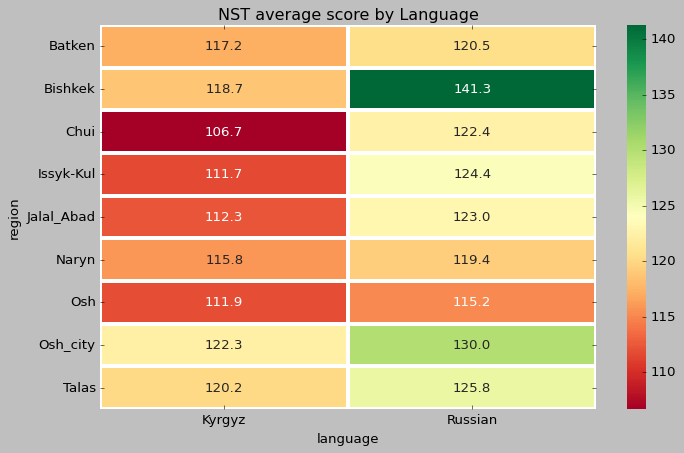

In [134]:
nsttest = nst.groupby(['region', 'language']).agg({'Avg_score': 'mean'}).reset_index()
nsttestpiv=nsttest.pivot(
    index = 'region',
    columns = 'language',
    values = 'Avg_score'
)
plt.figure(figsize=(10,6))
sns.heatmap(nsttestpiv, annot=True, cmap='RdYlGn', fmt=".1f", linewidths=2)
plt.title("NST average score by Language")
plt.xlabel("language")
plt.ylabel("region")
plt.show()


<Figure size 800x480 with 0 Axes>

<Axes: xlabel='language', ylabel='region'>

Text(0.5, 1.0, 'NST Award Average Score by Language')

Text(0.5, 24.999999999999986, 'Language')

Text(77.0, 0.5, 'Region')

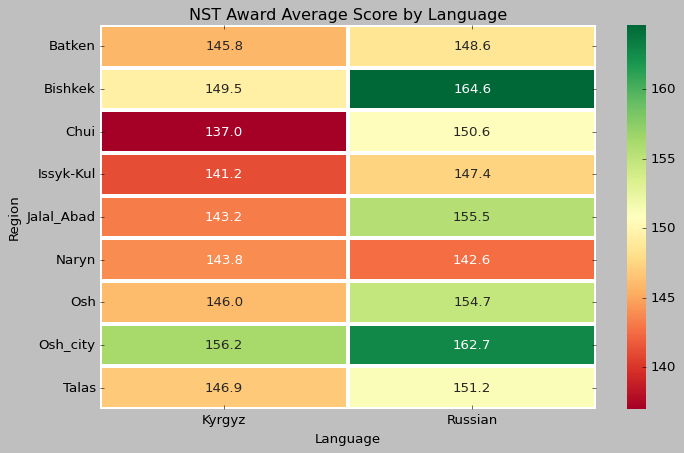

In [135]:
nsttest = nst.groupby(['region', 'language']).agg({'Award_average': 'mean'}).reset_index()
nsttestpiv=nsttest.pivot(
    index = 'region',
    columns = 'language',
    values = 'Award_average'
)
plt.figure(figsize=(10,6))
sns.heatmap(nsttestpiv, annot=True, cmap='RdYlGn', fmt=".1f", linewidths=2)
plt.title("NST Award Average Score by Language")
plt.xlabel("Language")
plt.ylabel("Region")
plt.show()


## EGRA

In [136]:
baselinecount = baseline.pivot_table(index=['region','language'],values=[
     'age'
     ],
aggfunc=['count'])
baselinecount

count
                      age
region     language      
Batken     Kyrgyz     140
           Russian     38
           Tajik       30
           Uzbek       93
Bishkek    Kyrgyz     129
           Russian    189
Chui       Kyrgyz     197
           Russian    144
Issyk-Kul  Kyrgyz     166
           Russian     64
Jalal-Abad Kyrgyz     311
           Russian    159
           Uzbek      110
Naryn      Kyrgyz      80
           Russian     16
Osh        Kyrgyz     283
           Russian    114
           Uzbek       40
Osh_city   Kyrgyz      19
           Russian    110
           Uzbek       10
Talas      Kyrgyz     100
           Russian     40

In [137]:
baselinemean = baseline.pivot_table(index=
 ['region', 'language'],
 values=[
     'oral_read_score_pcnt',
     'read_comp_score_pcnt',
     'word_score_pcnt',
     'invent_word_score_pcnt'],
aggfunc='mean')
baselinemean.round(2)

invent_word_score_pcnt  oral_read_score_pcnt  \
region     language                                                 
Batken     Kyrgyz                     62.86                 78.71   
           Russian                    47.37                 54.21   
           Tajik                      56.33                 65.70   
           Uzbek                      60.04                 83.20   
Bishkek    Kyrgyz                     66.23                 78.66   
           Russian                    76.57                 90.30   
Chui       Kyrgyz                     58.87                 71.76   
           Russian                    61.50                 72.76   
Issyk-Kul  Kyrgyz                     57.98                 76.13   
           Russian                    58.38                 70.05   
Jalal-Abad Kyrgyz                     46.47                 58.68   
           Russian                    51.51                 61.77   
           Uzbek                      38.98                 46.75   
Naryn      Kyrgyz                     55.55                 70.55   
           Russian                    67.88                 83.12   
Osh        Kyrgyz                     43.06                 54.58   
           Russian                    44.25                 48.84   
           Uzbek                      55.35                 70.62   
Osh_city   Kyrgyz                     54.53                 69.84   
           Russian                    59.64                 71.86   
           Uzbek                      41.20                 45.60   
Talas      Kyrgyz                     57.28                 74.49   
           Russian                    60.00                 73.95   

                     read_comp_score_pcnt  word_score_pcnt  
region     language                                         
Batken     Kyrgyz                   64.14            54.16  
           Russian                  27.37            37.34  
           Tajik                    41.33            72.23  
           Uzbek                    82.80            87.72  
Bishkek    Kyrgyz                   63.41            57.89  
           Russian                  79.89            65.68  
Chui       Kyrgyz                   58.88            78.37  
           Russian                  46.11            48.86  
Issyk-Kul  Kyrgyz                   59.64            54.92  
           Russian                  58.75            56.52  
Jalal-Abad Kyrgyz                   45.72            60.85  
           Russian                  34.72            47.72  
           Uzbek                    40.00            61.69  
Naryn      Kyrgyz                   56.50            62.06  
           Russian                  60.00            70.81  
Osh        Kyrgyz                   37.95            48.19  
           Russian                  18.95            33.39  
           Uzbek                    66.00            88.30  
Osh_city   Kyrgyz                   61.05            78.05  
           Russian                  46.36            55.32  
           Uzbek                    46.00            55.10  
Talas      Kyrgyz                   56.00            64.80  
           Russian                  49.00            53.30

In [162]:
# Define the subtask (column name)
subtask = "oral_read_score_pcnt"

# Filter dataframe for only this subtask
oralread = baseline[["region", subtask]].dropna()  # Remove missing values

# violin plot
fig = px.violin(oralread, x="region", y=subtask, color="region",
                box=True,  # to add mini box plot
                points="all",  # show every datapoint distributed
                title=f"Score Distribution for {subtask} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)


In [161]:
# Define the subtask (column name)
subtask2 = "read_comp_score_pcnt"

# Filter dataframe for only this subtask
readcomp = baseline[["region", subtask2]].dropna()

# Create the violin plot
fig = px.violin(readcomp, x="region", y=subtask2, color="region",
                box=True,
                points="all",
                title=f"Score Distribution for {subtask2} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)


In [160]:
# Define the subtask (column name)
subtask3 = "word_score_pcnt"

# Filter dataframe for only this subtask
wordscore = baseline[["region", subtask3]].dropna()  # Remove missing values

# Create the violin plot
fig = px.violin(wordscore, x="region", y=subtask3, color="region",
                box=True,  # Adds a mini box plot inside
                points="all",  # Show all data points
                title=f"Score Distribution for {subtask3} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)



In [159]:
# Define the subtask (column name)
subtask4 = "invent_word_score_pcnt"

# Filter dataframe for only this subtask
inventwordscore = baseline[["region", subtask4]].dropna()  # Remove missing values

# Create the violin plot
fig = px.violin(inventwordscore, x="region", y=subtask4, color="region",
                box=True,  # Adds a mini box plot inside
                points="all",  # Show all data points
                title=f"Score Distribution for {subtask4} Across Regions")

# Customize appearance
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Score",
    legend_title="Region",
    paper_bgcolor="white",
    font=dict(color="black")
)



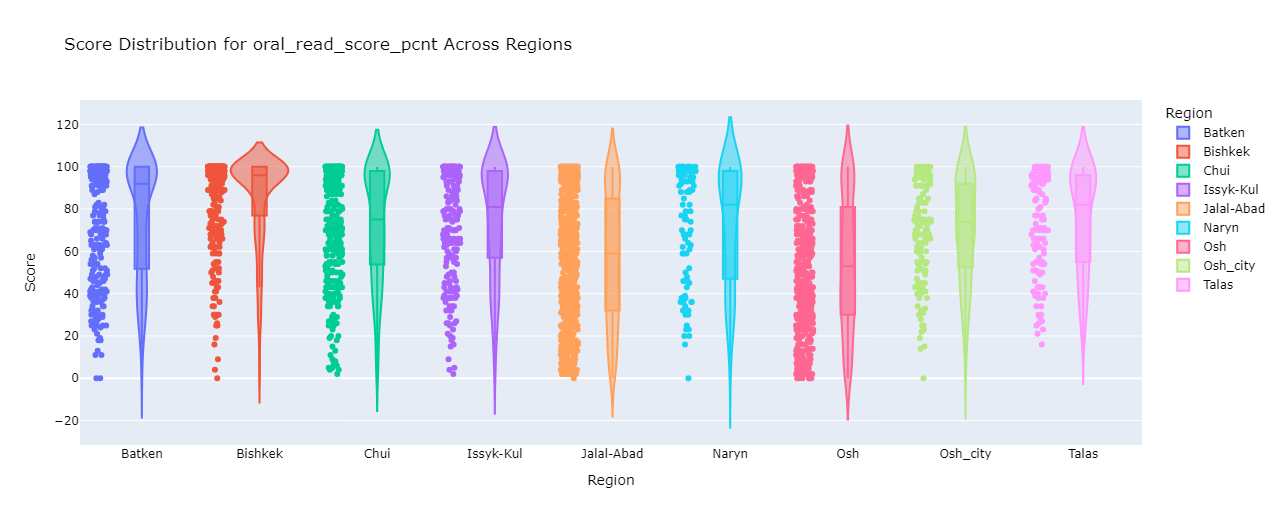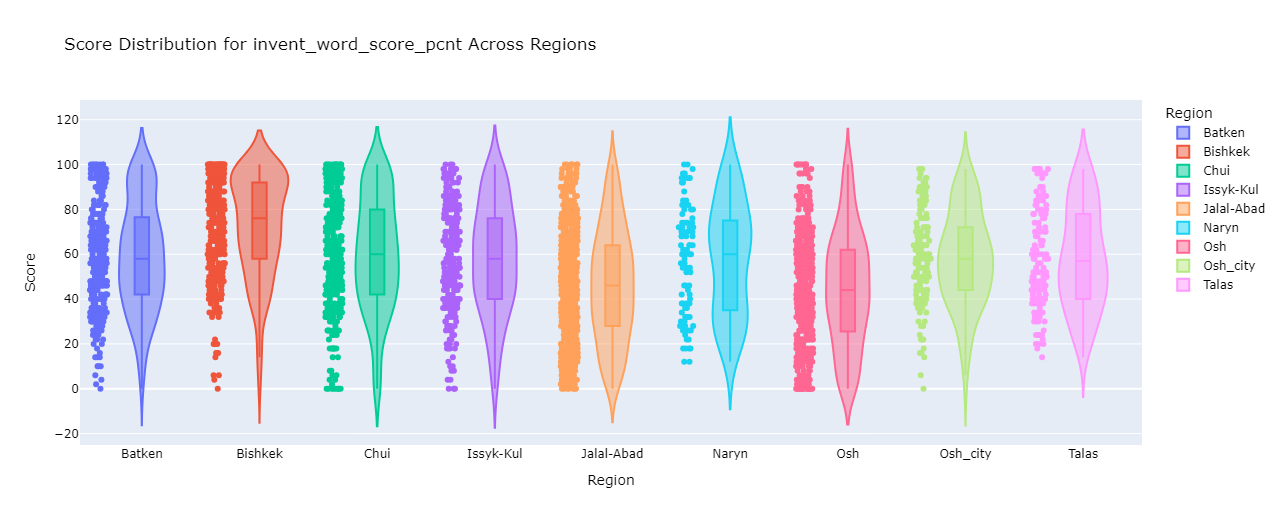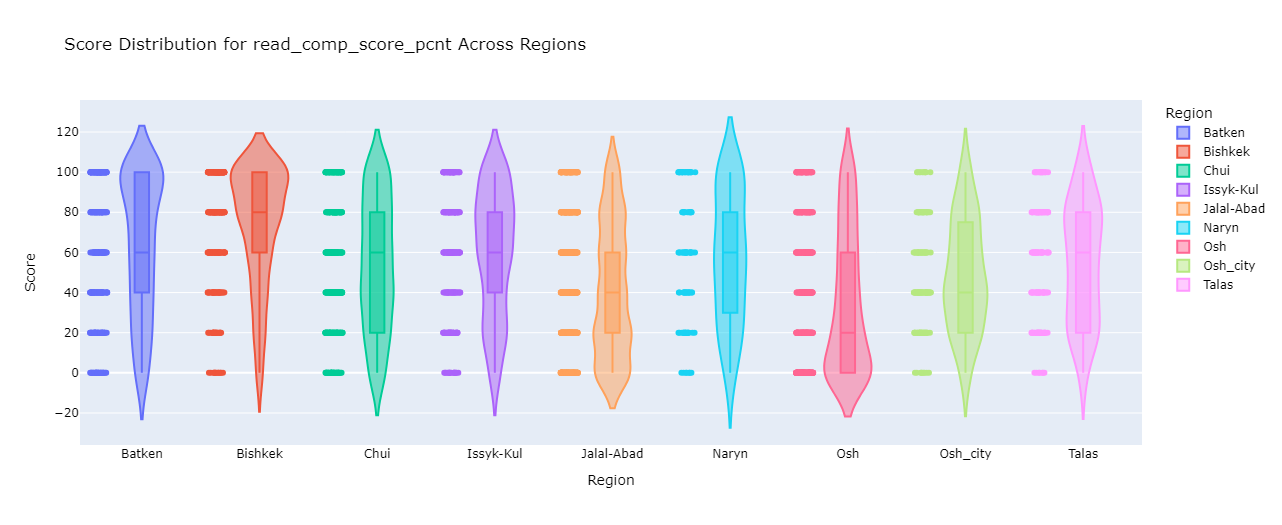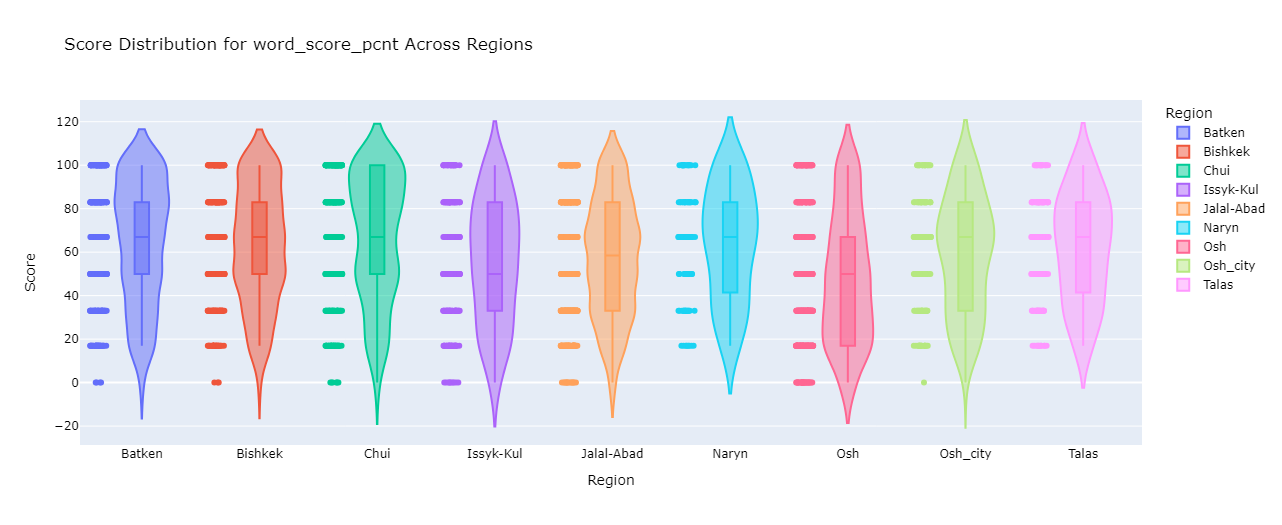

#Statistics

##ANOVA -one way test between regions for all subtasks

In [142]:
# One-way ANOVA across all regions
model = ols('oral_read_score_pcnt ~ C(region)', data=baseline).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq      df          F        PR(>F)
C(region)  2.855733e+05     8.0  46.892108  6.772220e-71
Residual   1.958699e+06  2573.0        NaN           NaN


In [143]:
# One-way ANOVA across all regions
model = ols('read_comp_score_pcnt ~ C(region)', data=baseline).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                 sum_sq      df          F        PR(>F)
C(region)  3.780006e+05     8.0  46.015606  1.379932e-69
Residual   2.642026e+06  2573.0        NaN           NaN


In [144]:
model=ols('word_score_pcnt ~ C(region)', data=baseline).fit()
anova_Table=sm.stats.anova_lm(model, typ=2)
print(anova_Table)

                 sum_sq      df          F        PR(>F)
C(region)  8.841147e+04     8.0  14.475468  7.590315e-21
Residual   1.964381e+06  2573.0        NaN           NaN


In [145]:
model=ols('invent_word_score_pcnt ~ C(region)', data=baseline).fit()
anova_Table=sm.stats.anova_lm(model, typ=2)
print(anova_Table)

                 sum_sq      df          F        PR(>F)
C(region)  2.059824e+05     8.0  43.353588  1.356524e-65
Residual   1.528111e+06  2573.0        NaN           NaN


Quick recap - there is a significant difference between regions for all four subtask scores. Will need to do a Tukey test to dig in more!

##ANOVA - one way test - Language within a region by subtask

###Oral Reading Score Score - between languages within a region

In [146]:
# List of regions
regions = baseline['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = baseline[baseline['region'] == region]
    model = ols('oral_read_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df          F        PR(>F)
C(language)   27057.548323    3.0  13.419231  3.091704e-08
Residual     199616.305498  297.0        NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df          F    PR(>F)
C(language)   10392.732819    1.0  24.361557  0.000001
Residual     134806.801772  316.0        NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df         F    PR(>F)
C(language)      83.601680    1.0  0.118575  0.730799
Residual     239013.759024  339.0       NaN       NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)    1710.704114    1.0  2.477204  0.116894
Residual     157451.943712  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df         F    PR(>F)
C(language)   16005.042902    2.0  8.860669  0.000162
Residual     521118.067443  577.0       NaN       NaN


ANOVA for Region: Naryn
       

Takeaways of ANOVA test within regions for the oral reading  subtask score - did language matter within the region?

1. Batken - significant as p <= .05
2. Bishkek - significant as p <= .05
3. Chui - not significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - significant as p <= .05
9. Talas - not significant as p > .05


###Reading Comprehension - between languages within a region

In [147]:
# List of regions
regions = baseline['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = baseline[baseline['region'] == region]
    model = ols('read_comp_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df          F        PR(>F)
C(language)   98955.200191    3.0  38.820759  3.400542e-21
Residual     252353.769909  297.0        NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df         F        PR(>F)
C(language)   20831.193483    1.0  26.74821  4.122955e-07
Residual     246097.108404  316.0       NaN           NaN


ANOVA for Region: Chui
                    sum_sq     df          F    PR(>F)
C(language)   13570.677133    1.0  13.644068  0.000257
Residual     337176.536943  339.0        NaN       NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)      36.469356    1.0  0.037748  0.846124
Residual     220278.313253  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df         F    PR(>F)
C(language)   13102.068924    2.0  6.306486  0.001953
Residual     599374.482800  577.0       NaN       NaN


ANOVA for Region: N

Oral Reading Comprehension  subtask, significance of language within regions
1. Batken - significant as p <= .05
2. Bishkek -  significant as p >= .05
3. Chui -  significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - not significant as p >= .05
9. Talas - not significant as p > .05

###Silent Reading Comprehension - between languages within a region

In [148]:
# List of regions
regions = baseline['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = baseline[baseline['region'] == region]
    model = ols('word_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df          F        PR(>F)
C(language)   94895.942044    3.0  65.745064  1.251100e-32
Residual     142895.871910  297.0        NaN           NaN


ANOVA for Region: Bishkek
                    sum_sq     df         F    PR(>F)
C(language)    4653.912911    1.0  6.647983  0.010379
Residual     221215.433001  316.0       NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df           F        PR(>F)
C(language)   72443.010357    1.0  116.787349  1.371596e-23
Residual     210281.171461  339.0         NaN           NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F    PR(>F)
C(language)     117.355436    1.0  0.146141  0.702606
Residual     183089.966303  228.0       NaN       NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df          F        PR(>F)
C(language)   20632.504730    2.0  15.301226  3.349587e-07
Residual     389019.652166  577.0        NaN           NaN


A

Word Score Percent subtask, significance of language within regions
1. Batken - significant as p <= .05
2. Bishkek - not significant as p >= .05
3. Chui -  significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - significant as p <= .05
9. Talas - not significant as p > .05

###Invented Word Score - between languages within a region

In [149]:
# List of regions
regions = baseline['region'].unique()

# Loop through regions and run ANOVA for each region
for region in regions:
    subset = baseline[baseline['region'] == region]
    model = ols('invent_word_score_pcnt ~ C(language)', data=subset).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"ANOVA for Region: {region}")
    print(anova_table)
    print("\n")

ANOVA for Region: Batken
                    sum_sq     df        F    PR(>F)
C(language)    7494.583537    3.0  4.47693  0.004307
Residual     165730.479586  297.0      NaN       NaN


ANOVA for Region: Bishkek
                    sum_sq     df          F    PR(>F)
C(language)    8195.408011    1.0  16.791331  0.000053
Residual     154231.308970  316.0        NaN       NaN


ANOVA for Region: Chui
                    sum_sq     df         F    PR(>F)
C(language)     574.067017    1.0  0.890813  0.345929
Residual     218461.827411  339.0       NaN       NaN


ANOVA for Region: Issyk-Kul
                    sum_sq     df         F   PR(>F)
C(language)       7.357255    1.0  0.012344  0.91163
Residual     135886.903614  228.0       NaN      NaN


ANOVA for Region: Jalal-Abad
                    sum_sq     df         F    PR(>F)
C(language)   10205.082087    2.0  8.288309  0.000283
Residual     355219.159292  577.0       NaN       NaN


ANOVA for Region: Naryn
                   sum_sq   

Takeaways of ANOVA test within regions for the invented word subtask score - did language matter within the region?

1. Batken - significant as p <= .05
2. Bishkek - significant as p <= .05
3. Chui - not significant as p > .05
4. Issyk-Kul - not significant as p > .05
5. Jalal-Abad - significant as p <= .05
6. Naryn - not significant as p >= .05
7. Osh - significant as p <= .05
8. Osh City - significant as p <= .05
9. Talas - not significant as p > .05


##Tukey Test

In [150]:
# Create a combined category for region and language
baseline['Region_Language'] = baseline['region'] + "_" + baseline['language']

# Run Tukey's test
tukey_results = pairwise_tukeyhsd(baseline['oral_read_score_pcnt'], baseline['Region_Language'])
oralreadtukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
oralreadtukey
# Print results
print(tukey_results)

<ipython-input-150-84fbd90bb87f>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-24.5038,0.0002,-42.4541,-6.5534,True
1,Batken_Kyrgyz,Batken_Tajik,-13.0143,0.7398,-32.7575,6.7289,False
2,Batken_Kyrgyz,Batken_Uzbek,4.4900,0.9999,-8.6377,17.6178,False
3,Batken_Kyrgyz,Bishkek_Kyrgyz,-0.0554,1.0000,-12.0320,11.9213,False
4,Batken_Kyrgyz,Bishkek_Russian,11.5873,0.0239,0.6447,22.5299,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,2.6264,1.0000,-10.9328,16.1855,False
249,Osh_city_Russian,Talas_Russian,2.0864,1.0000,-16.0328,20.2055,False
250,Osh_city_Uzbek,Talas_Kyrgyz,28.8900,0.1670,-3.6573,61.4373,False
251,Osh_city_Uzbek,Talas_Russian,28.3500,0.3062,-6.3455,63.0455,False


             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -24.5038 0.0002 -42.4541  -6.5534   True
     Batken_Kyrgyz       Batken_Tajik -13.0143 0.7398 -32.7575   6.7289  False
     Batken_Kyrgyz       Batken_Uzbek     4.49 0.9999  -8.6377  17.6178  False
     Batken_Kyrgyz     Bishkek_Kyrgyz  -0.0554    1.0  -12.032  11.9213  False
     Batken_Kyrgyz    Bishkek_Russian  11.5873 0.0239   0.6447  22.5299   True
     Batken_Kyrgyz        Chui_Kyrgyz  -6.9529 0.7847 -17.8005   3.8948  False
     Batken_Kyrgyz       Chui_Russian  -5.9504 0.9726 -17.5979   5.6971  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  -2.5818    1.0 -13.8423   8.6788  False
     Batken_Kyrgyz  Issyk-Kul_Russian  -8.6674 0.8945 -23.4748     6.14  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz -20.0358    0.

In [151]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(baseline['read_comp_score_pcnt'], baseline['Region_Language'])

# Print results
print(tukey_results)
readcomptukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
readcomptukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -36.7744    0.0 -57.1362 -16.4127   True
     Batken_Kyrgyz       Batken_Tajik -22.8095   0.04  -45.205  -0.4141   True
     Batken_Kyrgyz       Batken_Uzbek  18.6528 0.0014   3.7615  33.5441   True
     Batken_Kyrgyz     Bishkek_Kyrgyz   -0.732    1.0 -14.3176  12.8536  False
     Batken_Kyrgyz    Bishkek_Russian  15.7513  0.001   3.3387  28.1639   True
     Batken_Kyrgyz        Chui_Kyrgyz  -5.2596  0.997 -17.5645   7.0453  False
     Batken_Kyrgyz       Chui_Russian -18.0317 0.0002 -31.2439  -4.8196   True
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  -4.5043 0.9998 -17.2776    8.269  False
     Batken_Kyrgyz  Issyk-Kul_Russian  -5.3929    1.0 -22.1895  11.4037  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz -18.4194    0.

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-36.7744,0.0000,-57.1362,-16.4127,True
1,Batken_Kyrgyz,Batken_Tajik,-22.8095,0.0400,-45.2050,-0.4141,True
2,Batken_Kyrgyz,Batken_Uzbek,18.6528,0.0014,3.7615,33.5441,True
3,Batken_Kyrgyz,Bishkek_Kyrgyz,-0.7320,1.0000,-14.3176,12.8536,False
4,Batken_Kyrgyz,Bishkek_Russian,15.7513,0.0010,3.3387,28.1639,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,9.6364,0.8174,-5.7442,25.0170,False
249,Osh_city_Russian,Talas_Russian,2.6364,1.0000,-17.9168,23.1896,False
250,Osh_city_Uzbek,Talas_Kyrgyz,10.0000,1.0000,-26.9196,46.9196,False
251,Osh_city_Uzbek,Talas_Russian,3.0000,1.0000,-36.3564,42.3564,False


In [152]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(baseline['word_score_pcnt'], baseline['Region_Language'])
wordscoretukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# Print results
print(tukey_results)
wordscoretukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -16.8222 0.0531 -33.7312   0.0868  False
     Batken_Kyrgyz       Batken_Tajik   18.069 0.0696  -0.5288  36.6669  False
     Batken_Kyrgyz       Batken_Uzbek  33.5561    0.0  21.1899  45.9223   True
     Batken_Kyrgyz     Bishkek_Kyrgyz   3.7272 0.9999  -7.5547  15.0091  False
     Batken_Kyrgyz    Bishkek_Russian  11.5183 0.0108   1.2104  21.8261   True
     Batken_Kyrgyz        Chui_Kyrgyz  24.2063    0.0  13.9879  34.4246   True
     Batken_Kyrgyz       Chui_Russian  -5.3032 0.9856  -16.275   5.6686  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz   0.7574    1.0  -9.8499  11.3647  False
     Batken_Kyrgyz  Issyk-Kul_Russian   2.3513    1.0 -11.5971  16.2998  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz   6.6846 0.598

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-16.8222,0.0531,-33.7312,0.0868,False
1,Batken_Kyrgyz,Batken_Tajik,18.0690,0.0696,-0.5288,36.6669,False
2,Batken_Kyrgyz,Batken_Uzbek,33.5561,0.0000,21.1899,45.9223,True
3,Batken_Kyrgyz,Bishkek_Kyrgyz,3.7272,0.9999,-7.5547,15.0091,False
4,Batken_Kyrgyz,Bishkek_Russian,11.5183,0.0108,1.2104,21.8261,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,9.4818,0.5058,-3.2907,22.2544,False
249,Osh_city_Russian,Talas_Russian,-2.0182,1.0000,-19.0862,15.0498,False
250,Osh_city_Uzbek,Talas_Kyrgyz,9.7000,1.0000,-20.9592,40.3592,False
251,Osh_city_Uzbek,Talas_Russian,-1.8000,1.0000,-34.4828,30.8828,False


In [153]:
# Run Tukey's test
tukey_results = pairwise_tukeyhsd(baseline['invent_word_score_pcnt'], baseline['Region_Language'])
inventtukey = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# Print results
print(tukey_results)
inventtukey

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
     Batken_Kyrgyz     Batken_Russian -15.4887 0.0715 -31.4691   0.4917  False
     Batken_Kyrgyz       Batken_Tajik  -6.5238 0.9996 -24.1004  11.0527  False
     Batken_Kyrgyz       Batken_Uzbek  -2.8141    1.0 -14.5012    8.873  False
     Batken_Kyrgyz     Bishkek_Kyrgyz   3.3754    1.0  -7.2869  14.0377  False
     Batken_Kyrgyz    Bishkek_Russian  13.7143 0.0001   3.9725   23.456   True
     Batken_Kyrgyz        Chui_Kyrgyz   -3.984 0.9982 -13.6413   5.6732  False
     Batken_Kyrgyz       Chui_Russian  -1.3571    1.0 -11.7264   9.0121  False
     Batken_Kyrgyz   Issyk-Kul_Kyrgyz  -4.8812 0.9842 -14.9061   5.1436  False
     Batken_Kyrgyz  Issyk-Kul_Russian  -4.4821 0.9999 -17.6646   8.7003  False
     Batken_Kyrgyz  Jalal-Abad_Kyrgyz -16.3877    0.

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-15.4887,0.0715,-31.4691,0.4917,False
1,Batken_Kyrgyz,Batken_Tajik,-6.5238,0.9996,-24.1004,11.0527,False
2,Batken_Kyrgyz,Batken_Uzbek,-2.8141,1.0000,-14.5012,8.8730,False
3,Batken_Kyrgyz,Bishkek_Kyrgyz,3.3754,1.0000,-7.2869,14.0377,False
4,Batken_Kyrgyz,Bishkek_Russian,13.7143,0.0001,3.9725,23.4560,True
...,...,...,...,...,...,...,...
248,Osh_city_Russian,Talas_Kyrgyz,-2.3564,1.0000,-14.4275,9.7147,False
249,Osh_city_Russian,Talas_Russian,0.3636,1.0000,-15.7671,16.4943,False
250,Osh_city_Uzbek,Talas_Kyrgyz,16.0800,0.9354,-12.8954,45.0554,False
251,Osh_city_Uzbek,Talas_Russian,18.8000,0.8539,-12.0879,49.6879,False


##Tukey Analysis

In [154]:
oralreadtukey[oralreadtukey['reject'] == True]
#this is all of the cases where region + language led to rejecting the null hypothesis for this subtasks
#To guide interpretation - Batken kyrgyz did 24 points better than batken russian
#I need to review all of these, and most importantly, determine each direction!

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-24.5038,0.0002,-42.4541,-6.5534,True
4,Batken_Kyrgyz,Bishkek_Russian,11.5873,0.0239,0.6447,22.5299,True
9,Batken_Kyrgyz,Jalal-Abad_Kyrgyz,-20.0358,0.0000,-30.0235,-10.0482,True
10,Batken_Kyrgyz,Jalal-Abad_Russian,-16.9407,0.0000,-28.3141,-5.5673,True
11,Batken_Kyrgyz,Jalal-Abad_Uzbek,-31.9597,0.0000,-44.4631,-19.4564,True
...,...,...,...,...,...,...,...
231,Osh_Kyrgyz,Talas_Russian,19.3670,0.0051,2.7903,35.9436,True
232,Osh_Russian,Osh_Uzbek,21.7829,0.0028,3.7487,39.8171,True
234,Osh_Russian,Osh_city_Russian,23.0215,0.0000,9.9058,36.1373,True
236,Osh_Russian,Talas_Kyrgyz,25.6479,0.0000,12.2025,39.0933,True


In [155]:
readcomptukey[readcomptukey['reject'] == True]


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Batken_Kyrgyz,Batken_Russian,-36.7744,0.0000,-57.1362,-16.4127,True
1,Batken_Kyrgyz,Batken_Tajik,-22.8095,0.0400,-45.2050,-0.4141,True
2,Batken_Kyrgyz,Batken_Uzbek,18.6528,0.0014,3.7615,33.5441,True
4,Batken_Kyrgyz,Bishkek_Russian,15.7513,0.0010,3.3387,28.1639,True
6,Batken_Kyrgyz,Chui_Russian,-18.0317,0.0002,-31.2439,-4.8196,True
...,...,...,...,...,...,...,...
232,Osh_Russian,Osh_Uzbek,47.0526,0.0000,26.5958,67.5095,True
233,Osh_Russian,Osh_city_Kyrgyz,42.1053,0.0000,14.5213,69.6892,True
234,Osh_Russian,Osh_city_Russian,27.4163,0.0000,12.5386,42.2940,True
236,Osh_Russian,Talas_Kyrgyz,37.0526,0.0000,21.8011,52.3042,True


In [156]:
wordscoretukey[wordscoretukey['reject'] == True]


,group1,group2,meandiff,p-adj,lower,upper,reject
2,Batken_Kyrgyz,Batken_Uzbek,33.5561,0.0000,21.1899,45.9223,True
4,Batken_Kyrgyz,Bishkek_Russian,11.5183,0.0108,1.2104,21.8261,True
5,Batken_Kyrgyz,Chui_Kyrgyz,24.2063,0.0000,13.9879,34.4246,True
15,Batken_Kyrgyz,Osh_Russian,-20.7695,0.0000,-32.4313,-9.1078,True
16,Batken_Kyrgyz,Osh_Uzbek,34.1357,0.0000,17.5625,50.7089,True
...,...,...,...,...,...,...,...
237,Osh_Russian,Talas_Russian,19.9053,0.0049,2.9173,36.8932,True
239,Osh_Uzbek,Osh_city_Russian,-32.9818,0.0000,-50.0498,-15.9138,True
240,Osh_Uzbek,Osh_city_Uzbek,-33.2000,0.0413,-65.8828,-0.5172,True
241,Osh_Uzbek,Talas_Kyrgyz,-23.5000,0.0002,-40.7941,-6.2059,True


In [157]:
inventtukey[inventtukey['reject'] == True]


,group1,group2,meandiff,p-adj,lower,upper,reject
4,Batken_Kyrgyz,Bishkek_Russian,13.7143,0.0001,3.9725,23.4560,True
9,Batken_Kyrgyz,Jalal-Abad_Kyrgyz,-16.3877,0.0000,-25.2792,-7.4961,True
10,Batken_Kyrgyz,Jalal-Abad_Russian,-11.3477,0.0103,-21.4730,-1.2224,True
11,Batken_Kyrgyz,Jalal-Abad_Uzbek,-23.8753,0.0000,-35.0066,-12.7441,True
14,Batken_Kyrgyz,Osh_Kyrgyz,-19.7971,0.0000,-28.8241,-10.7700,True
...,...,...,...,...,...,...,...
228,Osh_Kyrgyz,Osh_city_Russian,16.5763,0.0000,6.7602,26.3924,True
230,Osh_Kyrgyz,Talas_Kyrgyz,14.2199,0.0001,4.0565,24.3833,True
231,Osh_Kyrgyz,Talas_Russian,16.9399,0.0069,2.1825,31.6974,True
234,Osh_Russian,Osh_city_Russian,15.3907,0.0005,3.7144,27.0671,True
